In [18]:
import os
import cv2

path = "../data/raw/kaggle_3m"

found = False

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".tif") and "_mask" not in file:
            img_path = os.path.join(root, file)
            mask_path = img_path.replace(".tif", "_mask.tif")

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            print("Image path:", img_path)
            print("Mask path:", mask_path)
            print("Image shape:", img.shape if img is not None else "Image not loaded")
            print("Mask shape:", mask.shape if mask is not None else "Mask not loaded")

            found = True
            break
    if found:
        break

print("Found:", found)

Image path: ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_1.tif
Mask path: ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_1_mask.tif
Image shape: (256, 256, 3)
Mask shape: (256, 256)
Found: True


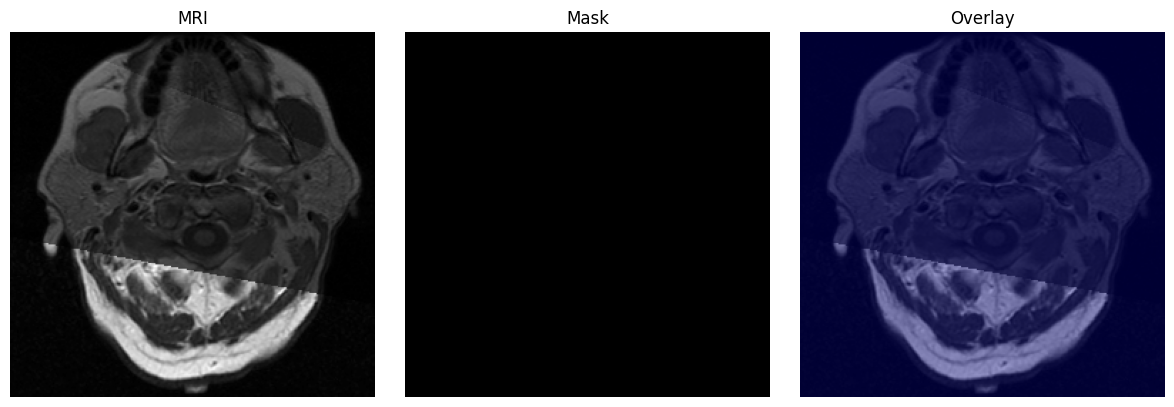

In [19]:
import matplotlib.pyplot as plt

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap="gray")
plt.imshow(mask, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()